# **Import Libraries**

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import GridSearchCV


from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# **Mount Drive**

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Load Data**

In [26]:
df=pd.read_csv('/content/drive/MyDrive/Projects/Titanic survival Prediction/Data/train (1).csv')
df.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
662,663,0,1,"Colley, Mr. Edward Pomeroy",male,47.0,0,0,5727,25.5875,E58,S
781,782,1,1,"Dick, Mrs. Albert Adrian (Vera Gillespie)",female,17.0,1,0,17474,57.0000,B20,S
208,209,1,3,"Carr, Miss. Helen ""Ellen""",female,16.0,0,0,367231,7.7500,NaN,Q
639,640,0,3,"Thorneycroft, Mr. Percival",male,NaN,1,0,376564,16.1000,NaN,S
13,14,0,3,"Andersson, Mr. Anders Johan",male,39.0,1,5,347082,31.2750,NaN,S
722,723,0,2,"Gillespie, Mr. William Henry",male,34.0,0,0,12233,13.0000,NaN,S
691,692,1,3,"Karun, Miss. Manca",female,4.0,0,1,349256,13.4167,NaN,C
740,741,1,1,"Hawksford, Mr. Walter James",male,NaN,0,0,16988,30.0000,D45,S
21,22,1,2,"Beesley, Mr. Lawrence",male,34.0,0,0,248698,13.0000,D56,S
389,390,1,2,"Lehmann, Miss. Bertha",female,17.0,0,0,SC 1748,12.0000,NaN,C


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# **EDA**

In [29]:
df['Survived'].value_counts(normalize=True)

,proportion
Survived,
0,0.616162
1,0.383838


<Axes: xlabel='Sex', ylabel='count'>

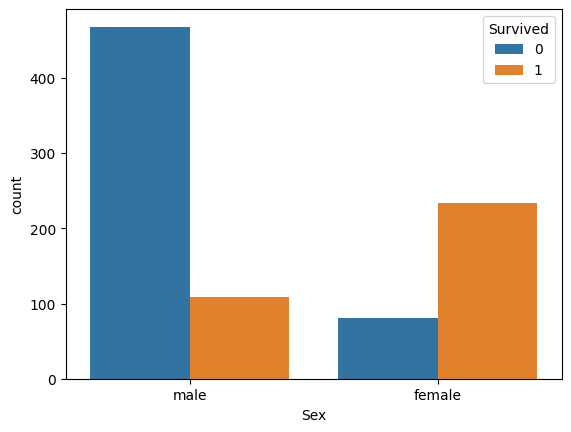

In [30]:
sns.countplot(x='Sex', hue='Survived', data=df)

<Axes: xlabel='Pclass', ylabel='count'>

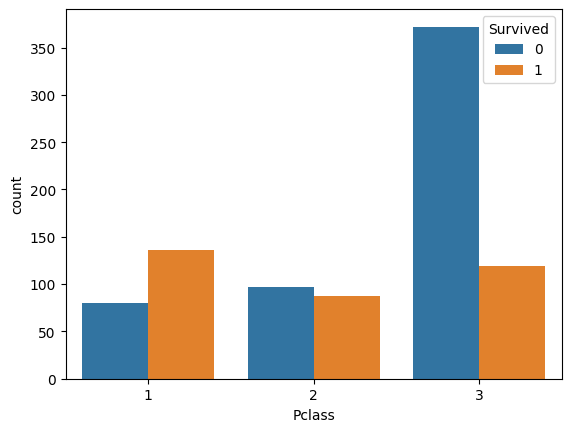

In [31]:
sns.countplot(x='Pclass', hue='Survived', data=df)

<Axes: xlabel='Survived', ylabel='Fare'>

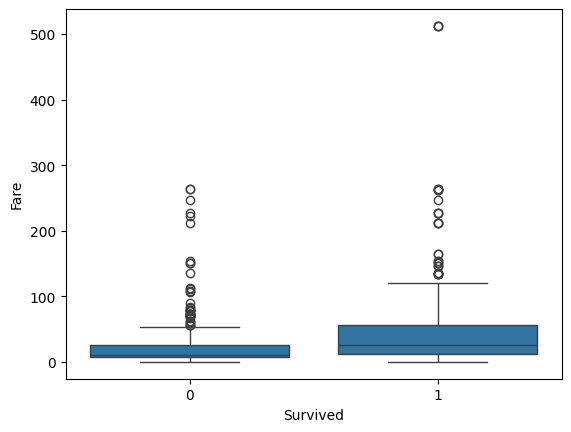

In [32]:
sns.boxplot(x='Survived', y='Fare', data=df)

# **Feature Engineering**

### Create New Feature

In [33]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [34]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_3714/172848211.py:1: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


### Drop useless columns

In [35]:
non_used_cols=['PassengerId', 'Name', 'Ticket', 'Cabin']
df=df.drop(non_used_cols,axis=1)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    object 
 3   Age         714 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   Embarked    889 non-null    object 
 8   FamilySize  891 non-null    int64  
 9   Title       891 non-null    object 
dtypes: float64(2), int64(5), object(3)
memory usage: 69.7+ KB


### Handling missing Values

In [38]:
df = df.fillna({
    'Age': df['Age'].median(),
    'Embarked': df['Embarked'].mode()[0]
})

## Encode Data

In [39]:
df = pd.get_dummies(df, drop_first=True)

In [40]:
df.sample(10)

,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,Sex_male,Embarked_Q,Embarked_S,Title_Col,Title_Countess,Title_Don,Title_Dr,Title_Jonkheer,Title_Lady,Title_Major,Title_Master,Title_Miss,Title_Mlle,Title_Mme,Title_Mr,Title_Mrs,Title_Ms,Title_Rev,Title_Sir
781,1,1,17.0,1,0,57.0000,2,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
850,0,3,4.0,4,2,31.2750,7,True,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
579,1,3,32.0,0,0,7.9250,1,True,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
274,1,3,28.0,0,0,7.7500,1,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
666,0,2,25.0,0,0,13.0000,1,True,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
815,0,1,28.0,0,0,0.0000,1,True,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
297,0,1,2.0,1,2,151.5500,4,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
851,0,3,74.0,0,0,7.7750,1,True,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
299,1,1,50.0,0,1,247.5208,2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
319,1,1,40.0,1,1,134.5000,3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False


# **Model training**

## Train test split

In [41]:
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Logistic Regression

In [43]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [44]:
y_pred = model.predict(X_test)

In [46]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8156424581005587

Confusion Matrix:
[[88 17]
 [16 58]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.84      0.84       105
           1       0.77      0.78      0.78        74

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



## Feature Importance

<Axes: >

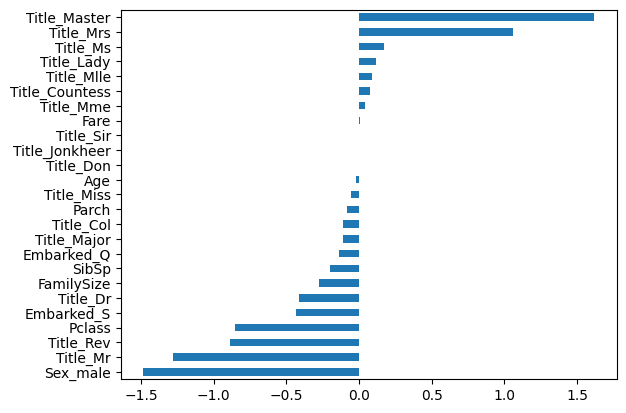

In [47]:
coeff = pd.Series(model.coef_[0], index=X.columns)
coeff.sort_values().plot(kind='barh')

## KNN Model

In [49]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

from sklearn.metrics import accuracy_score
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.7206703910614525


## Decision Tree Classifier

In [51]:
dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("DT Accuracy:", accuracy_score(y_test, y_pred_dt))

DT Accuracy: 0.8212290502793296


# Hypertuning DT model

In [58]:
params = {
    'max_depth': [3, 5, 7,8, 10],
    'min_samples_split': [2, 5,8,9,12],
    'min_samples_leaf': [1, 2,3, 4],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    params,
    cv=5,
    scoring='accuracy'
)

grid_dt.fit(X_train, y_train)

print("Best Params:", grid_dt.best_params_)

best_dt = grid_dt.best_estimator_

y_pred_h_dt = best_dt.predict(X_test)

from sklearn.metrics import accuracy_score
print("Tuned DT Accuracy:", accuracy_score(y_test, y_pred_h_dt))

Best Params: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 12}
Tuned DT Accuracy: 0.8100558659217877


In [60]:
Accuracy={
    'Logistic Regression' : [accuracy_score(y_test, y_pred)],
    'KNN' : [accuracy_score(y_test, y_pred_knn)],
    'Decision Tree Classifier' :[accuracy_score(y_test, y_pred_dt)],
    'Hyper_tuned(Decsion Tree)': [accuracy_score(y_test, y_pred_h_dt)]

}

In [62]:
Accuracy_df=pd.DataFrame(Accuracy, index=[0])


In [63]:
Accuracy_df

,Logistic Regression,KNN,Decision Tree Classifier,Hyper_tuned(Decsion Tree)
0,0.815642,0.72067,0.810056,0.810056
